0. Install and import libraries

In [1]:
!pip install easyocr
!pip install imutils

In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils


In [3]:
import os

# Avoid Intel MKL threading conflict (use for debugging purposes only)
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"


In [4]:
import easyocr

1. Read in image GRAYSCALE and BLUR

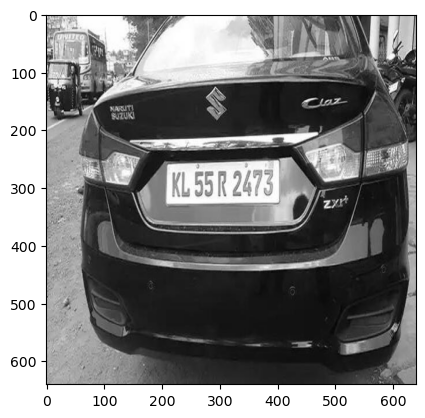

In [5]:
img = cv2.imread("b.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray,cv2.COLOR_BGR2RGB))

2. Apply filter and find edges 

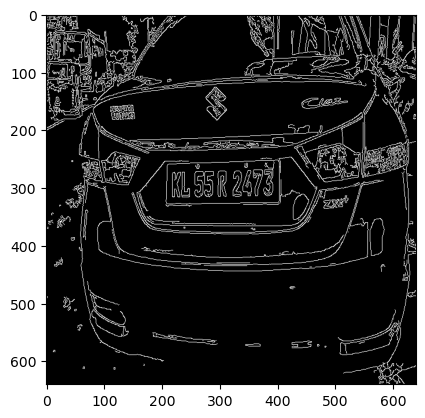

In [6]:
bfilter = cv2.bilateralFilter(gray,11,17,17)
edged = cv2.Canny(bfilter,30,200)
plt.imshow(cv2.cvtColor(edged,cv2.COLOR_BGR2RGB))

3. Find contours and apply mask

In [7]:
keypoints = cv2.findContours(edged.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours,key = cv2.contourArea,reverse = True) [:10]

In [8]:
location = None
for contour in contours :
    approx = cv2.approxPolyDP(contour,10,True)
    if len(approx) == 4:
        location = approx
        break

In [9]:
location

array([[[403, 256]],

       [[401, 326]],

       [[207, 324]],

       [[212, 259]]], dtype=int32)

In [10]:
mask = np.zeros(gray.shape,np.uint8)
new_image = cv2.drawContours(mask,[location],0,255,-1)
new_image = cv2.bitwise_and(img,img,mask = mask)

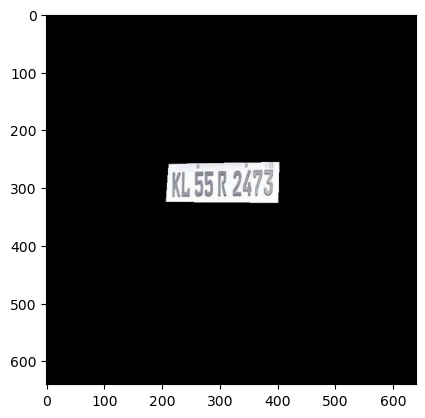

In [11]:
plt.imshow(cv2.cvtColor(new_image,cv2.COLOR_BGR2RGB))

In [12]:
(x,y) = np.where(mask == 255)
(x1,y1) = (np.min(x),np.min(y))
(x2,y2) = (np.max(x),np.max(y))
cropped_image = gray [x1:x2+1,y1:y2+1]

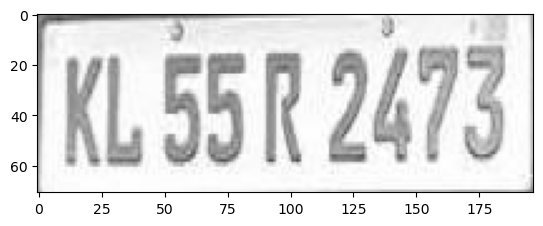

In [13]:
plt.imshow(cv2.cvtColor(cropped_image,cv2.COLOR_BGR2RGB))

4. Use Easy OCR to read text

In [14]:
reader = easyocr.Reader(["en"])
result = reader.readtext(cropped_image)
result

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[1, 5], [197, 5], [197, 69], [1, 69]], 'KL 55R 2473', 0.4479401583467176)]

5. Render result

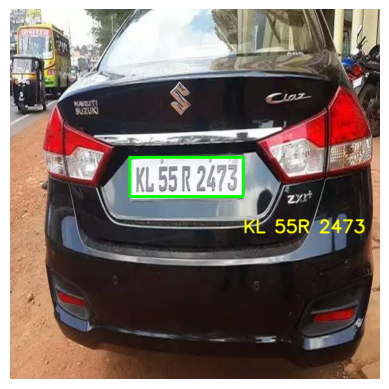

In [15]:
text = result[0][-2]  # Extraire le texte détecté
font = cv2.FONT_HERSHEY_SIMPLEX  # Choisir la police

# Ajouter du texte à l'image
res = cv2.putText(
    img, 
    text=text,  # Texte à ajouter
    org=(approx[0][0][0], approx[1][0][1] + 60),  # Position du texte
    fontFace=font,  # Police de caractères
    fontScale=1,  # Taille de la police
    color=(0, 255, 255),  # Couleur du texte (Jaune)
    thickness=2,  # Épaisseur du texte
    lineType=cv2.LINE_AA  # Type de ligne (antialiasing)
)

# Dessiner un rectangle autour de la zone approximative
res = cv2.rectangle(
    img, 
    tuple(approx[0][0]),  # Coin supérieur gauche
    tuple(approx[2][0]),  # Coin inférieur droit
    color=(0, 255, 0),  # Couleur du rectangle (Vert)
    thickness=3  # Épaisseur du rectangle
)

# Afficher l'image
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.axis("off")  # Désactiver l'affichage des axes
plt.show()


In [16]:
!pip install PySide6

In [17]:
import sys
import cv2
import numpy as np
import imutils
import easyocr
from PySide6.QtCore import Qt, QTimer
from PySide6.QtGui import QImage, QPixmap
from PySide6.QtWidgets import QApplication, QWidget, QPushButton, QLabel, QVBoxLayout, QHBoxLayout


class RealTimeLicensePlateDetector(QWidget):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Détection de Plaques en Temps Réel")
        self.setGeometry(100, 100, 800, 600)

        # Layout principal
        self.layout = QVBoxLayout()
        self.button_layout = QHBoxLayout()

        # Label pour afficher le flux vidéo
        self.image_label = QLabel("Aucune image affichée.")
        self.image_label.setAlignment(Qt.AlignCenter)
        self.layout.addWidget(self.image_label)

        # Boutons
        self.start_camera_button = QPushButton("Démarrer la caméra")
        self.start_camera_button.clicked.connect(self.start_camera)
        self.stop_camera_button = QPushButton("Arrêter la caméra")
        self.stop_camera_button.clicked.connect(self.stop_camera)
        self.stop_camera_button.setEnabled(False)

        self.button_layout.addWidget(self.start_camera_button)
        self.button_layout.addWidget(self.stop_camera_button)
        self.layout.addLayout(self.button_layout)

        self.setLayout(self.layout)

        # Attributs pour la caméra
        self.capture = None
        self.timer = QTimer()
        self.timer.timeout.connect(self.update_frame)

        # OCR Reader
        self.reader = easyocr.Reader(["en"], gpu=False)

    def start_camera(self):
        self.capture = cv2.VideoCapture(0)
        if not self.capture.isOpened():
            self.image_label.setText("Impossible de se connecter à la caméra.")
            return

        self.start_camera_button.setEnabled(False)
        self.stop_camera_button.setEnabled(True)
        self.timer.start(30)

    def stop_camera(self):
        self.timer.stop()
        if self.capture is not None:
            self.capture.release()
        self.image_label.setText("Caméra arrêtée.")
        self.start_camera_button.setEnabled(True)
        self.stop_camera_button.setEnabled(False)

    def update_frame(self):
        ret, frame = self.capture.read()
        if ret:
            # Convertir le cadre en niveaux de gris pour la détection
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            bfilter = cv2.bilateralFilter(gray, 11, 17, 17)
            edged = cv2.Canny(bfilter, 30, 200)

            # Trouver les contours
            keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            contours = imutils.grab_contours(keypoints)
            contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

            location = None
            for contour in contours:
                approx = cv2.approxPolyDP(contour, 10, True)
                if len(approx) == 4:
                    location = approx
                    break

            if location is not None:
                mask = np.zeros(gray.shape, np.uint8)
                new_image = cv2.drawContours(mask, [location], 0, 255, -1)
                new_image = cv2.bitwise_and(frame, frame, mask=mask)

                (x, y) = np.where(mask == 255)
                (x1, y1) = (np.min(x), np.min(y))
                (x2, y2) = (np.max(x), np.max(y))
                cropped_image = gray[x1:x2 + 1, y1:y2 + 1]

                # Lecture OCR
                result = self.reader.readtext(cropped_image)
                if result:
                    text = result[0][-2]
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    cv2.putText(frame, text, org=(location[0][0][0], location[1][0][1] + 60),
                                fontFace=font, fontScale=1, color=(0, 255, 255), thickness=2)
                    cv2.rectangle(frame, tuple(location[0][0]), tuple(location[2][0]),
                                  color=(0, 255, 0), thickness=3)

            # Affichage du flux vidéo
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, w, ch = frame_rgb.shape
            bytes_per_line = ch * w
            q_image = QImage(frame_rgb.data, w, h, bytes_per_line, QImage.Format_RGB888)
            self.image_label.setPixmap(QPixmap.fromImage(q_image))
        else:
            self.image_label.setText("Erreur lors de la récupération des images.")

if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = RealTimeLicensePlateDetector()
    window.show()
    sys.exit(app.exec())


Using CPU. Note: This module is much faster with a GPU.


SystemExit: 0

C:\Users\M S I\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
